# Dimensionless Fall Velocity — Marconi Beach, Cape Cod

**Author:** Chelsea Volpano  
**Email:** cvolpano@contractor.usgs.gov | cvolpano@gmail.com  
**Date:** 2026-06-24  
**Created using Claude Sonnet 4.6**

---

Calculates the dimensionless fall velocity (Ω) using:
- Grain size data (D50 in µm) from sediment CSV
- Wave data (Hs, Tp) from NDBC 44020 and WIS ST63064

Settling velocity formulations from Soulsby (1997) as implemented in:  
https://github.com/csherwood-usgs/IPython_notebook_examples/blob/master/settling.ipynb

**Dimensionless fall velocity:**  
Ω = Hb / (ws * T)  
where Hb is breaker height, ws is settling velocity, T is wave period.

Beach state classification (Wright & Short 1984):  
- Ω < 1: Reflective  
- 1 ≤ Ω ≤ 6: Intermediate  
- Ω > 6: Dissipative

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

%matplotlib inline

In [5]:
# ── Configuration ─────────────────────────────────────────────────────────────
OUT_DIR      = Path("wave_data")
PLOT_DIR     = Path("wave_plots")
GRAIN_FILE   = Path("caco-waves_grainsize.csv")   # update path as needed
PLOT_DIR.mkdir(exist_ok=True)

NDBC_FILE = OUT_DIR / "NDBC_44020_2024-10_to_2025-03.csv"
WIS_FILE  = OUT_DIR / "WIS_ST63064_2024-10_to_2024-12.csv"

START = "2024-10-01"
END   = "2025-03-31"

SURVEY_DATES = ["2024-10-23", "2025-01-23", "2025-03-06"]

# Physical constants
RHO_W   = 1025.0    # seawater density (kg/m³)
RHO_S   = 2650.0    # sediment density (kg/m³)
NU      = 1.36e-6   # kinematic viscosity of seawater at ~10°C (m²/s)
G       = 9.81      # gravitational acceleration (m/s²)

# Spectral colormap palette
_sp = plt.colormaps["Spectral"]
PALETTE = {
    "ndbc":      _sp(0.95),
    "ndbc_mean": _sp(0.85),
    "wis":       _sp(0.08),
    "wis_mean":  _sp(0.02),
    "survey":    _sp(0.55),
    "omega":     _sp(0.72),
}

## 1. Settling Velocity Formulations

From Soulsby (1997) *Dynamics of Marine Sands*, as in csherwood-usgs/IPython_notebook_examples.  
Three formulations are provided; Soulsby (1997) is used by default.

In [6]:
def settling_velocity(d_m, rho_s=RHO_S, rho_w=RHO_W, nu=NU, g=G, method="soulsby"):
    """
    Calculate settling velocity (m/s) for a grain of diameter d_m (metres).

    Methods:
      'soulsby'  — Soulsby (1997), valid for d = 0.063–2 mm
      'stokes'   — Stokes law (fine grains only, d < ~0.1 mm)
      'ferguson' — Ferguson & Church (2004)

    Parameters
    ----------
    d_m   : float or array — grain diameter in metres
    rho_s : float — sediment density (kg/m³)
    rho_w : float — fluid density (kg/m³)
    nu    : float — kinematic viscosity (m²/s)
    g     : float — gravitational acceleration (m/s²)
    method: str   — 'soulsby', 'stokes', or 'ferguson'

    Returns
    -------
    ws : float or array — settling velocity (m/s)
    """
    s   = rho_s / rho_w          # relative density
    Dstar = d_m * ((s - 1) * g / nu**2)**(1/3)  # dimensionless grain size

    if method == "soulsby":
        # Soulsby (1997) Eq. 102
        ws = (nu / d_m) * (np.sqrt(10.36**2 + 1.049 * Dstar**3) - 10.36)

    elif method == "stokes":
        # Stokes law
        ws = (s - 1) * g * d_m**2 / (18 * nu)

    elif method == "ferguson":
        # Ferguson & Church (2004)
        C1, C2 = 18.0, 1.0
        ws = ((s - 1) * g * d_m**2) / (C1 * nu + (0.75 * C2 * (s - 1) * g * d_m**3)**0.5)

    else:
        raise ValueError(f"Unknown method '{method}'. Choose 'soulsby', 'stokes', or 'ferguson'.")

    return ws

# Quick sanity check — 250 µm sand
d_test = 250e-6
for m in ["soulsby", "stokes", "ferguson"]:
    ws = settling_velocity(d_test, method=m)
    print(f"  {m:10s}: ws = {ws*100:.3f} cm/s  (d = {d_test*1e6:.0f} µm)")

  soulsby   : ws = 2.882 cm/s  (d = 250 µm)
  stokes    : ws = 3.971 cm/s  (d = 250 µm)
  ferguson  : ws = 2.559 cm/s  (d = 250 µm)


## 2. Load Grain Size Data

In [7]:
gs = pd.read_csv(GRAIN_FILE, encoding="latin1")  # latin1 handles µ symbol in headers

# Strip whitespace from column names
gs.columns = gs.columns.str.strip()

# Find D50 column — handles encoding variants of µm
d50_col = [c for c in gs.columns if "D50" in c and ("m" in c.lower() or "µ" in c or "Â" in c)]
if not d50_col:
    raise ValueError(f"Could not find D50 µm column. Available columns: {list(gs.columns)}")
d50_col = d50_col[0]
print(f"Using D50 column: '{d50_col}'")

gs["D50_m"] = pd.to_numeric(gs[d50_col], errors="coerce") * 1e-6  # µm → m
gs["ws_ms"] = settling_velocity(gs["D50_m"], method="soulsby")     # m/s
gs["ws_cms"] = gs["ws_ms"] * 100                                    # cm/s

# Parse sample date
date_col = [c for c in gs.columns if "DATE" in c.upper() and "COLLECTED" in c.upper()]
if date_col:
    gs["date"] = pd.to_datetime(gs[date_col[0]], errors="coerce")

print(f"\nLoaded {len(gs)} samples")
print(f"D50 range: {gs['D50_m'].min()*1e6:.1f} – {gs['D50_m'].max()*1e6:.1f} µm")
print(f"ws range:  {gs['ws_cms'].min():.3f} – {gs['ws_cms'].max():.3f} cm/s")
gs[["SAMPLE_ID", d50_col, "ws_cms"]].head()

Using D50 column: 'D50_Âµm'

Loaded 6 samples
D50 range: 253.9 – 727.4 µm
ws range:  2.948 – 9.128 cm/s


,SAMPLE_ID,D50_Âµm,ws_cms
0,CACO-G1,727.42,9.127732
1,CACO-G1_dup,716.16,9.019364
2,CACO-G2,270.55,3.233783
3,CACO-G2_dup,253.87,2.948269
4,CACO-G3,667.42,8.535205


## 3. Load Wave Data

In [8]:
def load_ndbc(path):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "datetime"
    df = df[["WVHT", "DPD"]].rename(columns={"WVHT": "Hs", "DPD": "Tp"})
    df = df.apply(pd.to_numeric, errors="coerce")
    df["Hs"] = df["Hs"].where(df["Hs"] < 99.0)
    df["Tp"] = df["Tp"].where(df["Tp"] < 99.0)
    return df.resample("1h").mean()

def load_wis(path):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "datetime"
    df = df[["waveHs", "waveTp"]].rename(columns={"waveHs": "Hs", "waveTp": "Tp"})
    df = df.apply(pd.to_numeric, errors="coerce")
    return df

ndbc = load_ndbc(NDBC_FILE)
print(f"NDBC loaded: {len(ndbc)} rows")

if WIS_FILE.exists():
    wis = load_wis(WIS_FILE)
    print(f"WIS loaded:  {len(wis)} rows")
else:
    wis = None
    print("WIS file not found.")

NDBC loaded: 4368 rows
WIS loaded:  2205 rows


## 4. Calculate Dimensionless Fall Velocity (Ω)

Ω = Hs / (ws × Tp)  

Using offshore Hs and Tp directly as a proxy for breaker conditions.  
A separate ws is computed for each survey sample and applied to the wave record.

In [9]:
def compute_omega(wave_df, ws):
    """
    Compute dimensionless fall velocity time series.
    Ω = Hs / (ws * Tp)
    """
    df = wave_df.copy()
    df["omega"] = df["Hs"] / (ws * df["Tp"])
    return df

# Use mean D50 across all samples as representative grain size
d50_mean = gs["D50_m"].mean()
ws_mean  = settling_velocity(d50_mean, method="soulsby")
print(f"Mean D50:  {d50_mean*1e6:.1f} µm")
print(f"Mean ws:   {ws_mean*100:.3f} cm/s")

ndbc_omega = compute_omega(ndbc, ws_mean)
if wis is not None:
    wis_omega = compute_omega(wis, ws_mean)

# Beach state thresholds
print(f"\nNDBC 44020 Ω — mean={ndbc_omega['omega'].mean():.2f}  "
      f"median={ndbc_omega['omega'].median():.2f}  "
      f"max={ndbc_omega['omega'].max():.2f}")
pct_reflective    = (ndbc_omega["omega"] < 1).mean() * 100
pct_intermediate  = ((ndbc_omega["omega"] >= 1) & (ndbc_omega["omega"] <= 6)).mean() * 100
pct_dissipative   = (ndbc_omega["omega"] > 6).mean() * 100
print(f"  Reflective   (Ω < 1):   {pct_reflective:.1f}%")
print(f"  Intermediate (1≤Ω≤6):  {pct_intermediate:.1f}%")
print(f"  Dissipative  (Ω > 6):   {pct_dissipative:.1f}%")

Mean D50:  534.8 µm
Mean ws:   7.070 cm/s

NDBC 44020 Ω — mean=2.29  median=2.26  max=5.13
  Reflective   (Ω < 1):   6.2%
  Intermediate (1≤Ω≤6):  76.8%
  Dissipative  (Ω > 6):   0.0%


## 5. Per-Sample Ω at Survey Dates

For each sediment sample, compute ws and look up the wave conditions at the nearest survey date.

In [10]:
results = []
for _, row in gs.iterrows():
    if pd.isna(row["ws_ms"]):
        continue
    ws = row["ws_ms"]
    # Find nearest survey date
    sample_date = row.get("date", pd.NaT)
    if pd.isna(sample_date):
        survey_date = pd.Timestamp(SURVEY_DATES[0])  # default to first survey
    else:
        survey_date = min(SURVEY_DATES, key=lambda d: abs(pd.Timestamp(d) - sample_date))
        survey_date = pd.Timestamp(survey_date)

    # Get wave conditions within ±12 hours of survey date
    window = ndbc_omega.loc[
        (ndbc_omega.index >= survey_date - pd.Timedelta(hours=12)) &
        (ndbc_omega.index <= survey_date + pd.Timedelta(hours=12))
    ]
    if window.empty:
        continue

    Hs_survey = window["Hs"].mean()
    Tp_survey = window["Tp"].mean()
    omega     = Hs_survey / (ws * Tp_survey)

    results.append({
        "SAMPLE_ID":   row["SAMPLE_ID"],
        "D50_um":      row["D50_m"] * 1e6,
        "ws_cms":      ws * 100,
        "survey_date": survey_date,
        "Hs_m":        Hs_survey,
        "Tp_s":        Tp_survey,
        "omega":       omega,
    })

results_df = pd.DataFrame(results)
print(results_df[["SAMPLE_ID", "D50_um", "ws_cms", "survey_date", "Hs_m", "Tp_s", "omega"]].to_string(index=False))

  SAMPLE_ID  D50_um   ws_cms survey_date   Hs_m    Tp_s    omega
    CACO-G1  727.42 9.127732  2025-01-23 0.3402 3.70375 1.006305
CACO-G1_dup  716.16 9.019364  2025-01-23 0.3402 3.70375 1.018396
    CACO-G2  270.55 3.233783  2025-01-23 0.3402 3.70375 2.840415
CACO-G2_dup  253.87 2.948269  2025-01-23 0.3402 3.70375 3.115484
    CACO-G3  667.42 8.535205  2025-01-23 0.3402 3.70375 1.076165
CACO-G3_dup  573.14 7.519072  2025-01-23 0.3402 3.70375 1.221598


## 6. Plots

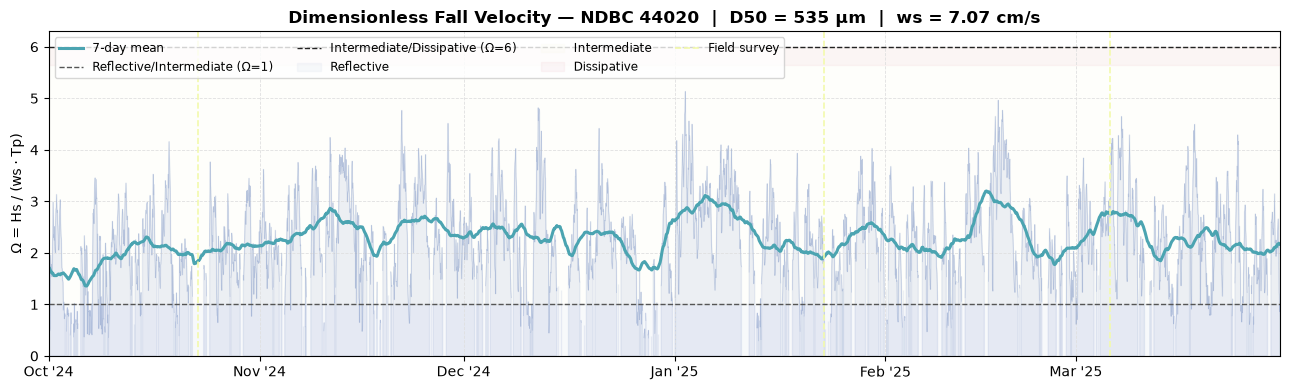

✓ Saved omega_timeseries.png


In [11]:
# ── Figure 1: Ω time series ───────────────────────────────────────────────────
date_fmt = mdates.DateFormatter("%b '%y")
date_loc = mdates.MonthLocator()

fig, ax = plt.subplots(figsize=(13, 4))

ax.fill_between(ndbc_omega.index, ndbc_omega["omega"], alpha=0.1, color=PALETTE["ndbc"])
ax.plot(ndbc_omega.index, ndbc_omega["omega"], color=PALETTE["ndbc"], lw=0.4, alpha=0.3)
ax.plot(ndbc_omega.index,
        ndbc_omega["omega"].rolling("7D", center=True, min_periods=24).mean(),
        color=PALETTE["ndbc_mean"], lw=2.2, label="7-day mean")

# Beach state threshold lines
ax.axhline(1, color="#555", lw=1.0, ls="--", label="Reflective/Intermediate (Ω=1)")
ax.axhline(6, color="#222", lw=1.0, ls="--", label="Intermediate/Dissipative (Ω=6)")

# Shade beach state regions
ymax = ndbc_omega["omega"].max() * 1.1
ax.axhspan(0, 1, alpha=0.04, color=_sp(0.95), label="Reflective")
ax.axhspan(1, 6, alpha=0.04, color=_sp(0.55), label="Intermediate")
ax.axhspan(6, ymax, alpha=0.04, color=_sp(0.08), label="Dissipative")

# Survey lines
for i, d in enumerate(SURVEY_DATES):
    ax.axvline(pd.Timestamp(d), color=PALETTE["survey"], lw=1.2, ls="--",
               label="Field survey" if i == 0 else "_nolegend_")

ax.set_ylabel("Ω = Hs / (ws · Tp)")
ax.set_title(f"Dimensionless Fall Velocity — NDBC 44020  |  D50 = {d50_mean*1e6:.0f} µm  |  ws = {ws_mean*100:.2f} cm/s",
             fontweight="bold")
ax.set_xlim(pd.Timestamp(START), pd.Timestamp(END))
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(date_loc)
ax.xaxis.set_major_formatter(date_fmt)
ax.legend(loc="upper left", ncol=4, fontsize=8.5)
ax.grid(color="#e0e0e0", linewidth=0.6, linestyle="--")

fig.tight_layout()
fig.savefig(PLOT_DIR / "omega_timeseries.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved omega_timeseries.png")

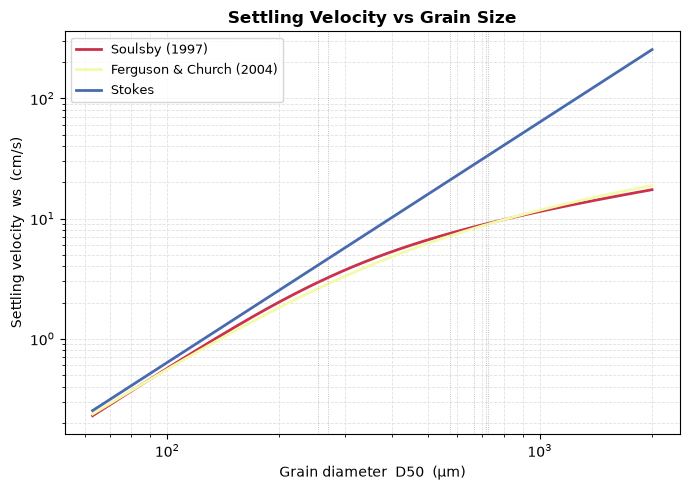

✓ Saved settling_velocity.png


In [12]:
# ── Figure 2: ws vs D50 for all formulations ──────────────────────────────────
d_range = np.logspace(np.log10(63e-6), np.log10(2000e-6), 200)  # 63 µm – 2 mm

fig2, ax2 = plt.subplots(figsize=(7, 5))
for method, color, label in [
    ("soulsby",  _sp(0.08), "Soulsby (1997)"),
    ("ferguson", _sp(0.55), "Ferguson & Church (2004)"),
    ("stokes",   _sp(0.95), "Stokes"),
]:
    ws_range = settling_velocity(d_range, method=method) * 100  # cm/s
    ax2.plot(d_range * 1e6, ws_range, lw=2, label=label,
             color=color)

# Mark sample D50s
for _, row in gs.iterrows():
    if not pd.isna(row["D50_m"]):
        ax2.axvline(row["D50_m"] * 1e6, color="grey", lw=0.6, ls=":", alpha=0.6)

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("Grain diameter  D50  (µm)")
ax2.set_ylabel("Settling velocity  ws  (cm/s)")
ax2.set_title("Settling Velocity vs Grain Size", fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(color="#e0e0e0", linewidth=0.6, linestyle="--", which="both")

fig2.tight_layout()
fig2.savefig(PLOT_DIR / "settling_velocity.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Saved settling_velocity.png")

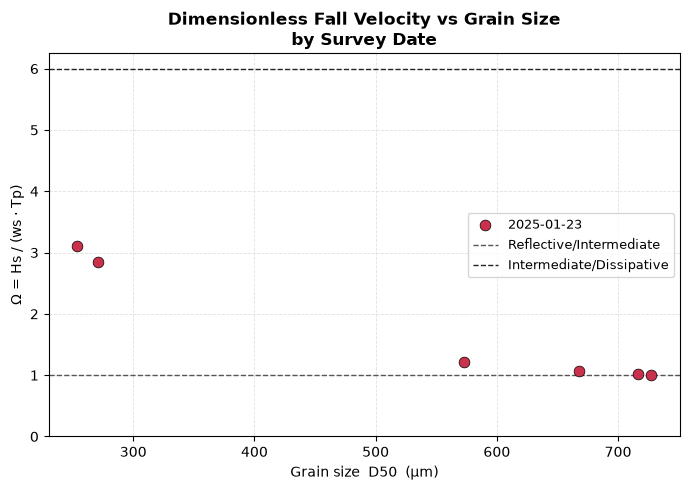

✓ Saved omega_vs_d50.png


In [13]:
# ── Figure 3: Ω vs D50 at survey dates ───────────────────────────────────────
if not results_df.empty:
    fig3, ax3 = plt.subplots(figsize=(7, 5))

    survey_colors = [_sp(0.08), _sp(0.55), _sp(0.95)]
    for (date, grp), col in zip(results_df.groupby("survey_date"), survey_colors):
        ax3.scatter(grp["D50_um"], grp["omega"], color=col, s=60,
                    edgecolors="k", linewidths=0.5, zorder=4,
                    label=pd.Timestamp(date).strftime("%Y-%m-%d"))

    ax3.axhline(1, color="#555", lw=1.0, ls="--", label="Reflective/Intermediate")
    ax3.axhline(6, color="#222", lw=1.0, ls="--", label="Intermediate/Dissipative")

    ax3.set_xlabel("Grain size  D50  (µm)")
    ax3.set_ylabel("Ω = Hs / (ws · Tp)")
    ax3.set_title("Dimensionless Fall Velocity vs Grain Size\nby Survey Date", fontweight="bold")
    ax3.legend(fontsize=9)
    ax3.set_ylim(bottom=0)
    ax3.grid(color="#e0e0e0", linewidth=0.6, linestyle="--")

    fig3.tight_layout()
    fig3.savefig(PLOT_DIR / "omega_vs_d50.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("✓ Saved omega_vs_d50.png")
else:
    print("No per-sample results to plot.")

In [ ]:
# ── Save results ──────────────────────────────────────────────────────────────
out_path = OUT_DIR / "dimensionless_fall_velocity.csv"
results_df.to_csv(out_path, index=False)
print(f"✓ Saved per-sample results → {out_path}")

omega_out = OUT_DIR / "omega_timeseries.csv"
ndbc_omega[["Hs", "Tp", "omega"]].to_csv(omega_out)
print(f"✓ Saved Ω time series → {omega_out}")